In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import src
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rc("text", usetex=True)
mpl.rc("font", family="serif")

/Users/gperaza/Research/informal-jobs-model/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
enoe = pd.read_parquet(ROOT / "outputs/enoe_harmonized.parquet")
od = pd.read_parquet(ROOT / "outputs/od_sector_imputed.parquet")
print(f"ENOE workers: {len(enoe):,}")
print(f"OD workers: {len(od):,}")

ENOE workers: 51,707
OD workers: 26,913


## Informality probability model

The ENOE survey observes whether each worker has a formal or informal job, whereas the OD survey does not contain this label. The objective of this stage is therefore to learn the relationship between informality and the harmonized worker characteristics available in both surveys. For an ENOE worker, the model estimates $P(I=1\mid X,S)$, where $I=1$ denotes informal employment, $X$ contains the common sociodemographic and labor attributes, and $S$ denotes economic sector. Sector is observed in ENOE but is uncertain for part of the OD population. Rather than replacing this uncertainty with a single hard sector label, the OD informality probability is obtained by marginalizing over the four possible sectors,

$$P(I_i=1\mid X_i)=\sum_s P(I_i=1\mid X_i,S_i=s)\,P(S_i=s\mid X_i).$$

For workers whose sector was originally observed, $P(S_i=s\mid X_i)$ is one-hot and the expression reduces to the usual conditional prediction. For workers whose sector was imputed, the full sector probability vector is retained. Models are trained using ENOE survey weights and selected primarily through weighted log loss so that predicted probabilities, rather than only hard formal/informal classifications, are the main output.

## Training geography

The informality model is trained using ENOE workers from municipalities represented in both ENOE and OD. This preserves the same geographic comparison used in the previous benchmark analysis.

In [3]:
enoe_informality, enoe_benchmark, training_municipalities, geography_summary = src.select_common_informality_population(enoe, od)
print(geography_summary.round(4))
print(f"ENOE workers used for training (whole state, non-metro municipalities as 'otro', quarters {sorted(enoe_informality['period'].unique())}): {len(enoe_informality):,}")
print(f"ENOE workers in the benchmark population (metro municipalities sampled by both surveys): {len(enoe_benchmark):,}")
outside = geography_summary[~geography_summary["enoe"]]
print(f"OD workers in metro municipalities not sampled by ENOE (scored by averaging over the sampled ones): {outside['od_workers'].sum():,} rows, {outside['od_weighted_share'].sum():.2%} of the weighted OD population ({', '.join(outside['municipio'])})")

                municipio   enoe    od  common  od_workers  od_weighted_share
0             guadalajara   True  True    True        3679             0.2737
1                 zapopan   True  True    True        8313             0.2964
2             tlaquepaque   True  True    True        2670             0.1235
3              tlajomulco   True  True    True        4551             0.1425
4                  tonala   True  True    True        2794             0.1025
5                el_salto   True  True    True        1861             0.0402
6             juanacatlan  False  True   False         750              0.005
7  ixtlahuacan_membrillos   True  True    True        1185             0.0085
8             zapotlanejo   True  True    True        1110             0.0078
ENOE workers used for training (whole state, non-metro municipalities as 'otro', quarters ['2022t1', '2022t2', '2022t3', '2022t4', '2023t1', '2023t2', '2023t3', '2023t4']): 51,707
ENOE workers in the benchmark population

To get an idea of what to expect from the model, we run a simple benchmark with the ENOE data to summarize the proportions and total counts of informal observations. 

In [4]:
informality_benchmark = src.calculate_enoe_informality_benchmark(enoe_benchmark)
display(informality_benchmark.round(4))
print("Benchmark by pooled quarter (rates unaffected by the weight rescaling):")
src.calculate_enoe_informality_by_period(enoe_benchmark).round(4)

,sample_workers,weighted_population,weighted_informal_population,unweighted_informality_rate,weighted_informality_rate,unspecified_sector_workers,unspecified_sector_weighted_share,unspecified_sector_informality_rate
0,38933,2410645.25,948580.25,0.4007,0.3935,156,0.0039,0.8465


Benchmark by pooled quarter (rates unaffected by the weight rescaling):


,period,sample_workers,weighted_informality_rate
0,2022t1,4831,0.3904
1,2022t2,4871,0.4015
2,2022t3,4781,0.3898
3,2022t4,4842,0.3933
4,2023t1,5280,0.3959
5,2023t2,4972,0.4049
6,2023t3,4809,0.3952
7,2023t4,4547,0.3756


In [5]:
from IPython.display import Markdown
b = informality_benchmark.iloc[0]
text = (f"The weighted informality rate in the metro benchmark population is **{b['weighted_informality_rate']:.2%}** ({b['sample_workers']:,} workers, {b['weighted_population']:,.0f} weighted). "
        f"{int(b['unspecified_sector_workers'])} of them ({b['unspecified_sector_weighted_share']:.2%} weighted) have an unspecified sector and are {b['unspecified_sector_informality_rate']:.0%} informal; they are kept in the population. "
        "The OD estimate is compared with this figure at the end of the notebook, after accounting for the composition differences between the two surveys.")
display(Markdown(text))

The weighted informality rate in the metro benchmark population is **39.35%** (38,933.0 workers, 2,410,645 weighted). 156 of them (0.39% weighted) have an unspecified sector and are 85% informal; they are kept in the population. The OD estimate is compared with this figure at the end of the notebook, after accounting for the composition differences between the two surveys.

## Predictor missingness

The common ENOE–OD predictors are inspected before training. Education is evaluated explicitly because missing education is considerably more frequent in OD than in ENOE.

In [6]:
predictor_columns = ["genero", "ocupacion", "edad_num", "escolaridad", "municipio", "estado_civil", "parentesco", "tamano_viv_cat", "sector", "lugar_trabajo"]
predictor_missingness = src.compare_informality_feature_missingness(enoe_benchmark, od, predictor_columns)
predictor_missingness.round(4)

,variable,enoe_missing_share,od_missing_share
0,genero,0.0000,0.0000
1,ocupacion,0.0000,0.0086
2,edad_num,0.0008,0.0000
3,escolaridad,0.0004,0.1580
4,municipio,0.0000,0.0000
5,estado_civil,0.0000,0.0085
6,parentesco,0.0000,0.0066
7,tamano_viv_cat,0.0000,0.0000
8,sector,0.0039,0.3019
9,lugar_trabajo,0.0038,0.1308


## Common ENOE train-test split

Based on the method used to divide the training and test sets for the sectoral allocation model, a held-out ENOE test sample is reserved before model tuning. Workers belonging to the same household are kept within the same partition.

In [7]:
enoe_informality_train, enoe_informality_test = src.split_enoe_informality_data(enoe_informality, n_splits=5, test_fold=0, random_state=42)
# Performance is judged where the model is applied: the metro municipalities. Non-metro test rows are dropped from the
# held-out set (they remain in the training folds).
enoe_informality_test = enoe_informality_test[enoe_informality_test["municipio"] != "otro"].reset_index(drop=True)
print(f"ENOE workers available for training: {len(enoe_informality_train):,} ({(enoe_informality_train['municipio'] == 'otro').sum():,} outside the metro area)")
print(f"ENOE metro workers reserved for testing: {len(enoe_informality_test):,} (all pooled quarters; households never straddle folds across quarters)")

ENOE workers available for training: 41,369 (10,394 outside the metro area)
ENOE metro workers reserved for testing: 7,958 (all pooled quarters; households never straddle folds across quarters)


Similar to what we did with the assignment of economic sectors, we created a hybrid model that accounts for the presence or absence of schooling. The only difference in this problem is that the training set is now the ENOE database. 

## Model A: predictors with education

For the first informality model (the specification that includes the education variable), we prepare the ENOE training data in the format required to train the classifiers. Here we obtain the predictor matrix $X$, containing the features defined in `src.INFORMALITY_FEATURES` that the model will use to learn informality; the target variable $y$, given by the binary informal attribute, where 1 represents an informal worker and 0 a formal worker; the weights associated with the ENOE `survey_weight`, which ensure that, during training and evaluation, observations contribute according to the population they represent $^{*}$; the household groups, which are used during cross-validation to ensure that workers belonging to the same household remain within the same fold; and the final dataframe containing the workers that actually participate in the training.

$^{*}$ The survey weights are normalized to a common scale while preserving their relative proportions, so that observations representing a larger share of the population retain greater influence during model fitting and evaluation.

In [8]:
with_education_features = src.INFORMALITY_FEATURES
X_with_education, y_with_education, weights_with_education, groups_with_education, training_with_education = src.prepare_enoe_informality_training_data(enoe_informality_train, features=with_education_features)
print(f"Workers used for training: {len(training_with_education):,}")
print(f"Households used for training: {groups_with_education.nunique():,}")

Workers used for training: 41,369
Households used for training: 3,916


Next, we train and evaluate several candidate models for the informality classification problem. Here, we determine which family of algorithms performs best and which hyperparameter configuration provides the best probabilistic performance within each algorithm.



In [9]:
from IPython.display import Markdown
models = src.build_informality_models()
lines = []
for name, config in models.items():
    grid = config["params"]; n = 1
    for values in grid.values(): n *= len(values)
    tuned = ", ".join(f"`{key.replace('classifier__', '')}`: {values}" for key, values in grid.items())
    lines.append(f"* **{name}** — tuned: {tuned} — configurations: {n}")
total = sum(int(__import__("math").prod(len(v) for v in c["params"].values())) for c in models.values())
text = "The candidate families and their grids (read from `src.src.build_informality_models`, so this list cannot drift from the code):\n\n" + "\n".join(lines) + f"\n\nIn total {total} configurations, each evaluated with 5-fold household-grouped `StratifiedGroupKFold` ({total * 5} fits). Gradient boosting runs without early stopping (its internal validation split ignores households); the number of iterations is tuned in the grouped CV instead. Within each family, and then across families, the simplest configuration whose paired fold-difference to the best is within one standard error is selected (`src.select_one_se`)."

display(Markdown(text))

The candidate families and their grids (read from `src.src.build_informality_models`, so this list cannot drift from the code):

* **LogisticRegression** — tuned: `C`: [0.1, 1.0, 10.0] — configurations: 3
* **RandomForest** — tuned: `max_leaf_nodes`: [25, 50, 100], `max_features`: ['sqrt', 0.7], `min_samples_leaf`: [1, 5] — configurations: 12
* **GradientBoosting** — tuned: `max_iter`: [50, 100, 200, 400], `learning_rate`: [0.05, 0.1], `max_leaf_nodes`: [15, 31], `l2_regularization`: [0.0, 1.0] — configurations: 32

In total 47 configurations, each evaluated with 5-fold household-grouped `StratifiedGroupKFold` (235 fits). Gradient boosting runs without early stopping (its internal validation split ignores households); the number of iterations is tuned in the grouped CV instead. Within each family, and then across families, the simplest configuration whose paired fold-difference to the best is within one standard error is selected (`src.select_one_se`).

As part of the preprocessing, age (`edad_num`) is treated as a numerical variable, while the remaining predictors—including economic sector—are treated as categorical variables. Missing categorical values are represented as `no_especificado`, and categorical predictors are transformed using one-hot encoding. For Logistic Regression, the numerical variable is additionally standardized.

It is important to distinguish survey weighting from class balancing. The ENOE survey_weight is used as a sample weight so that observations contribute according to the population they represent. However, no additional artificial class balancing is applied (`class_weight=None`), meaning that formal or informal workers are not artificially upweighted during training.

Because the objective is to obtain informative probabilities of informality rather than only binary classifications, model selection is primarily based on the weighted binary log loss:

$$\mathcal{L} = -\frac{\sum_i w_i\left[ y_i\log(p_i)+(1-y_i)\log(1-p_i) \right]}{\sum_i w_i},$$


where $w_i$ is the ENOE survey weight associated with observation $i$, $y_i\in{0,1}$ is its observed informality status, and $p_i=P(Y_i=1\mid X_i)$ is the predicted probability of being informal. Lower values of $\mathcal{L}$ indicate better probabilistic predictions.

After evaluating all candidate configurations, the resulting summary reports:

* algorithm
* weighted log loss
* weighted log-loss standard deviation across folds
* weighted Brier score
* weighted balanced accuracy
* weighted accuracy
* weighted F1 score
* weighted ROC AUC
* best hyperparameters

In [10]:
with_education_summary, with_education_models = src.tune_informality_models(X_with_education, y_with_education, weights_with_education, groups_with_education, features=with_education_features, cv_splits=5, random_state=42)
with_education_summary

Tuning LogisticRegression: 3 parameter combinations


Tuning RandomForest: 12 parameter combinations


Tuning GradientBoosting: 32 parameter combinations


,model,weighted_log_loss,weighted_log_loss_std,weighted_brier_score,weighted_balanced_accuracy,weighted_accuracy,weighted_f1,weighted_roc_auc,best_params,fold_log_losses,mean_diff_vs_best,se_diff_vs_best,within_one_se,complexity_rank,selected
0,GradientBoosting,0.436877,0.007340,0.142557,0.788226,0.791647,0.767024,0.871492,"{'classifier__l2_regularization': 1.0, 'classi...","[0.43985622197914476, 0.44965798003375407, 0.4...",0.000000,0.000000,True,3,True
1,RandomForest,0.442761,0.006817,0.143900,0.787666,0.790906,0.766971,0.869280,"{'classifier__max_features': 0.7, 'classifier_...","[0.4436326726176951, 0.4534994066913839, 0.444...",0.005884,0.001477,False,2,False
2,LogisticRegression,0.476909,0.004730,0.156432,0.769271,0.772584,0.746357,0.850029,{'classifier__C': 1.0},"[0.47252399722251665, 0.480925029250456, 0.481...",0.040033,0.003580,False,1,False


In [11]:
with_education_best_name, with_education_best_model = src.get_best_informality_model(with_education_summary, with_education_models)
print(f"Best model with education: {with_education_best_name}")
print(with_education_summary.loc[with_education_summary["model"] == with_education_best_name, "best_params"].iloc[0])

Best model with education: GradientBoosting
{'classifier__l2_regularization': 1.0, 'classifier__learning_rate': 0.05, 'classifier__max_iter': 200, 'classifier__max_leaf_nodes': 31}


In [12]:
# Per-fold log losses (same household folds; sd across folds is variability, not a standard error). The second table
# re-runs the selected configuration with the ENOE sampling unit (survey_psu) as the CV group: households in the same
# unit share neighbourhood-level drivers, so this is the more demanding generalization estimate.
display(src.fold_table(with_education_summary).round(4))
with_education_psu_cv = src.cross_validate_grouped(with_education_best_model, X_with_education, y_with_education, weights_with_education, training_with_education["survey_psu"].astype(str))
pd.DataFrame({"household-grouped": src.fold_table(with_education_summary).loc[with_education_best_name].iloc[:5], "psu-grouped": with_education_psu_cv}).assign(difference=lambda t: t["psu-grouped"] - t["household-grouped"]).round(4)

,fold_0,fold_1,fold_2,fold_3,fold_4,mean,sd_across_folds
GradientBoosting,0.4399,0.4497,0.4346,0.4295,0.4307,0.4369,0.0082
RandomForest,0.4436,0.4535,0.4441,0.4324,0.4402,0.4428,0.0076
LogisticRegression,0.4725,0.4809,0.4815,0.4700,0.4796,0.4769,0.0053


,household-grouped,psu-grouped,difference
fold_0,0.4399,0.4397,-0.0001
fold_1,0.4497,0.4494,-0.0003
fold_2,0.4346,0.4406,0.0060
fold_3,0.4295,0.4334,0.0039
fold_4,0.4307,0.4249,-0.0058


In [13]:
from IPython.display import Markdown
sm = with_education_summary.set_index("model"); sel = sm[sm["selected"]].iloc[0]; best = sm["weighted_log_loss"].idxmin()
params = ", ".join(f"`{k.replace('classifier__', '')}` = {v}" for k, v in sel["best_params"].items())
runner = sm.drop(index=sel.name)["weighted_log_loss"].idxmin()
text = (f"**{sel.name}** is selected for Model A (weighted CV log loss {sel['weighted_log_loss']:.4f}; {runner}: {sm.loc[runner, 'weighted_log_loss']:.4f}, paired difference {sm.loc[runner, 'mean_diff_vs_best']:+.4f} ± {sm.loc[runner, 'se_diff_vs_best']:.4f} SE, "
        f"{'within' if sm.loc[runner, 'within_one_se'] else 'outside'} one standard error). Selected hyperparameters: {params}. "
        + ("The simplest family within one SE of the best was preferred." if sel.name != best else "It is also the best mean log loss."))
display(Markdown(text))

**GradientBoosting** is selected for Model A (weighted CV log loss 0.4369; RandomForest: 0.4428, paired difference +0.0059 ± 0.0015 SE, outside one standard error). Selected hyperparameters: `l2_regularization` = 1.0, `learning_rate` = 0.05, `max_iter` = 200, `max_leaf_nodes` = 31. It is also the best mean log loss.

Now, we take the best Model A specification (the Random Forest with the optimal hyperparameter settings) and evaluate it on the held-out ENOE test set. These workers were not used during model tuning or hyperparameter selection, so this stage provides an independent assessment of the model's out-of-sample performance.

In [14]:
with_education_metrics, with_education_confusion, with_education_calibration = src.evaluate_informality_model(with_education_best_model, enoe_informality_test, features=with_education_features)
with_education_metrics.round(4)

# Isotonic recalibration learned from household-grouped out-of-fold predictions on the training fold, compared on the
# same held-out metro households. ECE = expected calibration error; slope/intercept from a weighted logistic fit of
# the outcome on logit(p): (1, 0) is perfect, slope < 1 over-confident.
with_education_calibrated_model = src.calibrate_informality_model(with_education_best_model, enoe_informality_train, features=with_education_features)
with_education_comparison, with_education_comparison_tables = src.compare_informality_models({"sin calibrar": with_education_best_model, "isotónico": with_education_calibrated_model}, enoe_informality_test, features=with_education_features)
with_education_comparison[["weighted_log_loss", "weighted_brier_score", "weighted_roc_auc", "observed_informality_rate", "predicted_informality_rate", "calibration_gap_pp", "ece", "calibration_slope", "calibration_intercept"]].round(4)

,weighted_log_loss,weighted_brier_score,weighted_roc_auc,observed_informality_rate,predicted_informality_rate,calibration_gap_pp,ece,calibration_slope,calibration_intercept
sin calibrar,0.4180,0.1334,0.8752,0.4036,0.4033,-0.0221,0.0131,1.0527,0.0288
isotónico,0.4193,0.1339,0.8743,0.4036,0.4030,-0.0515,0.0165,1.0350,0.0233


In [15]:
# Held-out metrics with household-bootstrap 95% intervals (500 resamples of test households) and the weighted-marginal baseline
with_education_uncertainty = src.informality_test_metrics_with_uncertainty(with_education_best_model, enoe_informality_test, features=with_education_features)
with_education_uncertainty.round(4)

,estimate,ci_low,ci_high,bootstrap_sd
weighted_log_loss,0.4180,0.3995,0.4411,0.0103
marginal_log_loss,0.6744,0.6653,0.6826,0.0044
weighted_roc_auc,0.8752,0.8595,0.8872,0.0070
calibration_gap_pp,-0.0221,-1.3742,1.1946,0.6680
relative_improvement_over_marginal,0.3803,NaN,NaN,NaN


In [16]:
from IPython.display import Markdown
m = with_education_metrics.iloc[0]; u = with_education_uncertainty
text = (f"On the held-out metro households the selected model reaches a weighted accuracy of {m['weighted_accuracy']:.1%} and a weighted balanced accuracy of {m['weighted_balanced_accuracy']:.1%}; the weighted F1 for the informal class is {m['weighted_f1']:.3f}. "
        f"The weighted ROC AUC of {m['weighted_roc_auc']:.3f} [{u.loc['weighted_roc_auc', 'ci_low']:.3f}, {u.loc['weighted_roc_auc', 'ci_high']:.3f}] indicates good discrimination. The weighted log loss is {m['weighted_log_loss']:.4f} [{u.loc['weighted_log_loss', 'ci_low']:.4f}, {u.loc['weighted_log_loss', 'ci_high']:.4f}], "
        f"{u.loc['relative_improvement_over_marginal', 'estimate']:.1%} below the weighted-marginal baseline ({u.loc['marginal_log_loss', 'estimate']:.4f}); the Brier score is {m['weighted_brier_score']:.4f}.\n\n"
        f"At the population level the observed weighted informality rate in this test fold is {m['observed_informality_rate']:.2%} and the mean predicted probability {m['predicted_informality_rate']:.2%}: a gap of {m['calibration_gap_pp']:+.2f} percentage points "
        f"[{u.loc['calibration_gap_pp', 'ci_low']:+.2f}, {u.loc['calibration_gap_pp', 'ci_high']:+.2f}], whose interval {'includes' if u.loc['calibration_gap_pp', 'ci_low'] <= 0 <= u.loc['calibration_gap_pp', 'ci_high'] else 'excludes'} zero. The per-fold table above shows that the sign of this gap varies across folds, so it should be read as fold variability rather than a systematic bias.")
display(Markdown(text))

On the held-out metro households the selected model reaches a weighted accuracy of 81.3% and a weighted balanced accuracy of 79.1%; the weighted F1 for the informal class is 0.745. The weighted ROC AUC of 0.875 [0.860, 0.887] indicates good discrimination. The weighted log loss is 0.4180 [0.3995, 0.4411], 38.0% below the weighted-marginal baseline (0.6744); the Brier score is 0.1334.

At the population level the observed weighted informality rate in this test fold is 40.36% and the mean predicted probability 40.33%: a gap of -0.02 percentage points [-1.37, +1.19], whose interval includes zero. The per-fold table above shows that the sign of this gap varies across folds, so it should be read as fold variability rather than a systematic bias.

In [17]:
with_education_confusion.round(2)

,formal,informal
formal,266368.62,27543.38
informal,64436.00,134422.25


In [18]:
from IPython.display import Markdown
cmx = with_education_confusion; tn, fp, fn, tp = cmx.loc["formal", "formal"], cmx.loc["formal", "informal"], cmx.loc["informal", "formal"], cmx.loc["informal", "informal"]
text = (f"Under a 0.5 threshold, about {tn:,.0f} population-equivalent formal workers are classified as formal and {fp:,.0f} as informal; among informal workers {tp:,.0f} are identified and {fn:,.0f} missed. "
        f"That is an informal-worker recall of {tp / (tp + fn):.1%} and a specificity of {tn / (tn + fp):.1%} for formal workers — the model is better at the formal class, which is why balanced accuracy is below overall accuracy. "
        "The final application does not rely on this threshold: the primary output is the probability itself.")
display(Markdown(text))

Under a 0.5 threshold, about 266,369 population-equivalent formal workers are classified as formal and 27,543 as informal; among informal workers 134,422 are identified and 64,436 missed. That is an informal-worker recall of 67.6% and a specificity of 90.6% for formal workers — the model is better at the formal class, which is why balanced accuracy is below overall accuracy. The final application does not rely on this threshold: the primary output is the probability itself.

In [19]:
with_education_calibration.round(4)

,bin,sample_workers,weighted_population,weighted_informal,weighted_probability,observed_rate,predicted_probability
0,"(-0.001, 0.1]",1482,99905.125,6360.125,6875.6207,0.0637,0.0688
1,"(0.1, 0.2]",1452,87791.750,13501.000,12954.6846,0.1538,0.1476
2,"(0.2, 0.3]",1155,69284.750,16819.250,17288.5377,0.2428,0.2495
3,"(0.3, 0.4]",700,41318.125,13257.625,14278.3643,0.3209,0.3456
4,"(0.4, 0.5]",583,32504.875,14498.000,14444.5400,0.4460,0.4444
5,"(0.5, 0.6]",325,19603.375,10524.125,10711.9551,0.5369,0.5464
6,"(0.6, 0.7]",377,23247.875,16007.375,15134.9039,0.6886,0.6510
7,"(0.7, 0.8]",356,20866.125,14999.375,15634.1966,0.7188,0.7493
8,"(0.8, 0.9]",343,21553.625,18153.375,18498.4340,0.8422,0.8583
9,"(0.9, 1.0]",1185,76694.625,74738.000,72927.9511,0.9745,0.9509


In [20]:
from IPython.display import Markdown
t = with_education_calibration; m = with_education_metrics.iloc[0]
worst = t.iloc[(t["observed_rate"] - t["predicted_probability"]).abs().idxmax()]
text = (f"Calibration is assessed by grouping workers into predicted-probability bins and comparing the mean prediction with the observed weighted informality rate; a calibrated model satisfies P(Y=1 | p̂ = p) ≈ p. "
        f"The expected calibration error (population-weighted mean absolute deviation from the diagonal) is {m['ece']:.3f}; the calibration slope is {m['calibration_slope']:.2f} "
        f"({'slightly under-confident: probabilities are compressed toward the middle' if m['calibration_slope'] > 1.05 else 'slightly over-confident' if m['calibration_slope'] < 0.95 else 'close to 1'}). "
        f"The largest bin deviation is in {worst['bin']} (predicted {worst['predicted_probability']:.1%}, observed {worst['observed_rate']:.1%}, {int(worst['sample_workers'])} workers). "
        "The comparison with isotonic recalibration follows below.")
display(Markdown(text))

Calibration is assessed by grouping workers into predicted-probability bins and comparing the mean prediction with the observed weighted informality rate; a calibrated model satisfies P(Y=1 | p̂ = p) ≈ p. The expected calibration error (population-weighted mean absolute deviation from the diagonal) is 0.013; the calibration slope is 1.05 (slightly under-confident: probabilities are compressed toward the middle). The largest bin deviation is in (0.6, 0.7] (predicted 65.1%, observed 68.9%, 377 workers). The comparison with isotonic recalibration follows below.

## Model B: predictors without education

We now construct a second informality model that excludes the education attribute from the predictor set. 

The preparation procedure is otherwise identical to that used for Model A. We obtain the predictor matrix $X$, now using the variables defined in `src.INFORMALITY_ROBUST_FEATURES`; the binary target variable $y$, where 1 represents informal employment and 0 formal employment; the normalized ENOE survey weights; the household groups used during grouped cross-validation; and the final dataframe containing the workers that participate in training.

By removing education from the predictor set, this model serves as a robust fallback specification for OD workers whose educational information is unavailable.

In [21]:
without_education_features = src.INFORMALITY_ROBUST_FEATURES
X_without_education, y_without_education, weights_without_education, groups_without_education, training_without_education = src.prepare_enoe_informality_training_data(enoe_informality_train, features=without_education_features)
print(f"Workers used for training: {len(training_without_education):,}")
print(f"Households used for training: {groups_without_education.nunique():,}")

Workers used for training: 41,369
Households used for training: 3,916


As for the Machine Learning models, we use the same three candidate algorithms considered for Model A, with the same hyperparameter search spaces, fixed settings, grouped cross-validation procedure, survey weighting strategy, and primary model-selection metric. The only difference is that education is excluded from the predictor set.

In [22]:
without_education_summary, without_education_models = src.tune_informality_models(X_without_education, y_without_education, weights_without_education, groups_without_education, features=without_education_features, cv_splits=5, random_state=42)
without_education_summary

Tuning LogisticRegression: 3 parameter combinations


Tuning RandomForest: 12 parameter combinations


Tuning GradientBoosting: 32 parameter combinations


,model,weighted_log_loss,weighted_log_loss_std,weighted_brier_score,weighted_balanced_accuracy,weighted_accuracy,weighted_f1,weighted_roc_auc,best_params,fold_log_losses,mean_diff_vs_best,se_diff_vs_best,within_one_se,complexity_rank,selected
0,GradientBoosting,0.456459,0.007364,0.149227,0.779240,0.783335,0.754623,0.857194,"{'classifier__l2_regularization': 1.0, 'classi...","[0.45544847966275437, 0.4701467563735144, 0.45...",0.000000,0.000000,True,3,True
1,RandomForest,0.459881,0.008380,0.150273,0.777963,0.781983,0.753329,0.855433,"{'classifier__max_features': 0.7, 'classifier_...","[0.45722120516140624, 0.475278508906126, 0.457...",0.003422,0.000781,False,2,False
2,LogisticRegression,0.502896,0.005066,0.165818,0.753397,0.758020,0.723435,0.829210,{'classifier__C': 1.0},"[0.4945976210481569, 0.5071163532664602, 0.506...",0.046437,0.003444,False,1,False


In [23]:
without_education_best_name, without_education_best_model = src.get_best_informality_model(without_education_summary, without_education_models)
print(f"Best model without education: {without_education_best_name}")
print(without_education_summary.loc[without_education_summary["model"] == without_education_best_name, "best_params"].iloc[0])

Best model without education: GradientBoosting
{'classifier__l2_regularization': 1.0, 'classifier__learning_rate': 0.05, 'classifier__max_iter': 100, 'classifier__max_leaf_nodes': 31}


In [24]:
# Per-fold log losses (same household folds; sd across folds is variability, not a standard error). The second table
# re-runs the selected configuration with the ENOE sampling unit (survey_psu) as the CV group: households in the same
# unit share neighbourhood-level drivers, so this is the more demanding generalization estimate.
display(src.fold_table(without_education_summary).round(4))
without_education_psu_cv = src.cross_validate_grouped(without_education_best_model, X_without_education, y_without_education, weights_without_education, training_without_education["survey_psu"].astype(str))
pd.DataFrame({"household-grouped": src.fold_table(without_education_summary).loc[without_education_best_name].iloc[:5], "psu-grouped": without_education_psu_cv}).assign(difference=lambda t: t["psu-grouped"] - t["household-grouped"]).round(4)

,fold_0,fold_1,fold_2,fold_3,fold_4,mean,sd_across_folds
GradientBoosting,0.4554,0.4701,0.4544,0.4478,0.4545,0.4565,0.0082
RandomForest,0.4572,0.4753,0.4570,0.4499,0.4599,0.4599,0.0094
LogisticRegression,0.4946,0.5071,0.5061,0.4994,0.5072,0.5029,0.0057


,household-grouped,psu-grouped,difference
fold_0,0.4554,0.4576,0.0021
fold_1,0.4701,0.4678,-0.0023
fold_2,0.4544,0.4573,0.0028
fold_3,0.4478,0.4560,0.0082
fold_4,0.4545,0.4471,-0.0074


In [25]:
from IPython.display import Markdown
sm = without_education_summary.set_index("model"); sel = sm[sm["selected"]].iloc[0]; sa = with_education_summary.set_index("model"); sela = sa[sa["selected"]].iloc[0]
params = ", ".join(f"`{k.replace('classifier__', '')}` = {v}" for k, v in sel["best_params"].items())
text = (f"**{sel.name}** is selected for Model B (weighted CV log loss {sel['weighted_log_loss']:.4f}, Brier {sel['weighted_brier_score']:.4f}, ROC AUC {sel['weighted_roc_auc']:.4f}); hyperparameters: {params}. "
        f"Compared with Model A the CV log loss rises from {sela['weighted_log_loss']:.4f} to {sel['weighted_log_loss']:.4f} and the ROC AUC falls from {sela['weighted_roc_auc']:.4f} to {sel['weighted_roc_auc']:.4f}: education carries information about informality, but the model without it retains most of the predictive capacity.")
display(Markdown(text))

**GradientBoosting** is selected for Model B (weighted CV log loss 0.4565, Brier 0.1492, ROC AUC 0.8572); hyperparameters: `l2_regularization` = 1.0, `learning_rate` = 0.05, `max_iter` = 100, `max_leaf_nodes` = 31. Compared with Model A the CV log loss rises from 0.4369 to 0.4565 and the ROC AUC falls from 0.8715 to 0.8572: education carries information about informality, but the model without it retains most of the predictive capacity.

Now, just as for Model A, we take the best Model B specification, and evaluate it on the same held-out ENOE test set.

In [26]:
without_education_metrics, without_education_confusion, without_education_calibration = src.evaluate_informality_model(without_education_best_model, enoe_informality_test, features=without_education_features)
without_education_metrics.round(4)

# Isotonic recalibration learned from household-grouped out-of-fold predictions on the training fold, compared on the
# same held-out metro households. ECE = expected calibration error; slope/intercept from a weighted logistic fit of
# the outcome on logit(p): (1, 0) is perfect, slope < 1 over-confident.
without_education_calibrated_model = src.calibrate_informality_model(without_education_best_model, enoe_informality_train, features=without_education_features)
without_education_comparison, without_education_comparison_tables = src.compare_informality_models({"sin calibrar": without_education_best_model, "isotónico": without_education_calibrated_model}, enoe_informality_test, features=without_education_features)
without_education_comparison[["weighted_log_loss", "weighted_brier_score", "weighted_roc_auc", "observed_informality_rate", "predicted_informality_rate", "calibration_gap_pp", "ece", "calibration_slope", "calibration_intercept"]].round(4)

,weighted_log_loss,weighted_brier_score,weighted_roc_auc,observed_informality_rate,predicted_informality_rate,calibration_gap_pp,ece,calibration_slope,calibration_intercept
sin calibrar,0.4373,0.1394,0.8604,0.4036,0.4033,-0.0270,0.0151,1.1295,0.0734
isotónico,0.4360,0.1393,0.8602,0.4036,0.4015,-0.2071,0.0113,1.0421,0.0393


In [27]:
# Held-out metrics with household-bootstrap 95% intervals (500 resamples of test households) and the weighted-marginal baseline
without_education_uncertainty = src.informality_test_metrics_with_uncertainty(without_education_best_model, enoe_informality_test, features=without_education_features)
without_education_uncertainty.round(4)

,estimate,ci_low,ci_high,bootstrap_sd
weighted_log_loss,0.4373,0.4198,0.4598,0.0097
marginal_log_loss,0.6744,0.6653,0.6826,0.0044
weighted_roc_auc,0.8604,0.8453,0.8737,0.0075
calibration_gap_pp,-0.0270,-1.5165,1.2744,0.7051
relative_improvement_over_marginal,0.3516,NaN,NaN,NaN


#### Does the without-education model work for the people it is used on?

Model B is applied to the OD workers whose education is missing, but ENOE has virtually no such workers, so far it has only been tested on workers *with* education. Two checks on the same held-out metro households: (i) A and B on identical rows, so the cost of dropping education is explicit, and (ii) the same rows **reweighted to the covariate profile of the OD workers with missing education** (a weighted logistic classifier separating those OD workers from the ENOE test rows on the shared features gives each ENOE row the odds ratio $f_{OD\,missing}(x)/f_{ENOE}(x)$). Under the MAR-given-$x$ assumption that the pipeline makes, (ii) is the relevant performance of B. The effective sample size shows how much the reweighting concentrates on a subset of rows.

In [28]:
od_missing_education = od[src.identify_missing_category(od["escolaridad"])].copy()
od_missing_education.loc[~od_missing_education["municipio"].isin(training_municipalities), "municipio"] = "no_especificado"
profile_comparison, profile_diagnostics = src.evaluate_on_od_profile(
    {"A (con escolaridad)": with_education_best_model, "B (sin escolaridad)": without_education_best_model},
    enoe_informality_test, od_missing_education,
    features_by_model={"A (con escolaridad)": with_education_features, "B (sin escolaridad)": without_education_features},
)
print(f"OD workers with missing education: {len(od_missing_education):,} ({od_missing_education['expansion_factor'].sum() / od['expansion_factor'].sum():.1%} weighted)")
print("Reweighting diagnostics:"); print(profile_diagnostics.round(3).to_string())
profile_comparison[["weighted_log_loss", "weighted_brier_score", "weighted_roc_auc", "observed_informality_rate", "predicted_informality_rate", "calibration_gap_pp", "ece", "calibration_slope"]].round(4)

OD workers with missing education: 5,195 (15.8% weighted)
Reweighting diagnostics:
rows                       7958.000
effective_sample_size      3842.235
top_decile_weight_share       0.263
odds_ratio_median             0.855
odds_ratio_p90                1.866


weighted_log_loss  \
weighting                 model                                    
survey weights            A (con escolaridad)             0.4180   
                          B (sin escolaridad)             0.4373   
OD non-respondent profile A (con escolaridad)             0.4150   
                          B (sin escolaridad)             0.4307   

                                               weighted_brier_score  \
weighting                 model                                       
survey weights            A (con escolaridad)                0.1334   
                          B (sin escolaridad)                0.1394   
OD non-respondent profile A (con escolaridad)                0.1311   
                          B (sin escolaridad)                0.1353   

                                               weighted_roc_auc  \
weighting                 model                                   
survey weights            A (con escolaridad)            0.8752   
                          B (sin escolaridad)            0.8604   
OD non-respondent profile A (con escolaridad)            0.8509   
                          B (sin escolaridad)            0.8302   

                                               observed_informality_rate  \
weighting                 model                                            
survey weights            A (con escolaridad)                     0.4036   
                          B (sin escolaridad)                     0.4036   
OD non-respondent profile A (con escolaridad)                     0.3196   
                          B (sin escolaridad)                     0.3196   

                                               predicted_informality_rate  \
weighting                 model                                             
survey weights            A (con escolaridad)                      0.4033   
                          B (sin escolaridad)                      0.4033   
OD non-respondent profile A (con escolaridad)                      0.3242   
                          B (sin escolaridad)                      0.3256   

                                               calibration_gap_pp     ece  \
weighting                 model                                             
survey weights            A (con escolaridad)             -0.0221  0.0131   
                          B (sin escolaridad)             -0.0270  0.0151   
OD non-respondent profile A (con escolaridad)              0.4600  0.0167   
                          B (sin escolaridad)              0.5990  0.0184   

                                               calibration_slope  
weighting                 model                                   
survey weights            A (con escolaridad)             1.0527  
                          B (sin escolaridad)             1.1295  
OD non-respondent profile A (con escolaridad)             1.0273  
                          B (sin escolaridad)             1.1255

In [29]:
from IPython.display import Markdown
a = with_education_metrics.iloc[0]; b = without_education_metrics.iloc[0]
text = (f"On the same held-out households, weighted accuracy moves from {a['weighted_accuracy']:.1%} (Model A) to {b['weighted_accuracy']:.1%} (Model B), balanced accuracy from {a['weighted_balanced_accuracy']:.1%} to {b['weighted_balanced_accuracy']:.1%}, F1 from {a['weighted_f1']:.3f} to {b['weighted_f1']:.3f}, ROC AUC from {a['weighted_roc_auc']:.3f} to {b['weighted_roc_auc']:.3f}, "
        f"log loss from {a['weighted_log_loss']:.4f} to {b['weighted_log_loss']:.4f} and Brier from {a['weighted_brier_score']:.4f} to {b['weighted_brier_score']:.4f}. "
        f"The aggregate gap is {b['calibration_gap_pp']:+.2f} pp for Model B vs {a['calibration_gap_pp']:+.2f} pp for Model A. Model B is a usable fallback for workers without education; the masked evaluation below checks it on the profile of those workers.")
display(Markdown(text))

On the same held-out households, weighted accuracy moves from 81.3% (Model A) to 80.9% (Model B), balanced accuracy from 79.1% to 78.7%, F1 from 0.745 to 0.739, ROC AUC from 0.875 to 0.860, log loss from 0.4180 to 0.4373 and Brier from 0.1334 to 0.1394. The aggregate gap is -0.03 pp for Model B vs -0.02 pp for Model A. Model B is a usable fallback for workers without education; the masked evaluation below checks it on the profile of those workers.

In [30]:
without_education_confusion.round(2)

,formal,informal
formal,265663.12,28248.88
informal,65784.75,133073.50


In [31]:
from IPython.display import Markdown
cmx = without_education_confusion; ca = with_education_confusion
rec = lambda x: x.loc["informal", "informal"] / (x.loc["informal", "informal"] + x.loc["informal", "formal"]); spec = lambda x: x.loc["formal", "formal"] / (x.loc["formal", "formal"] + x.loc["formal", "informal"])
text = (f"Under the 0.5 threshold Model B identifies {rec(cmx):.1%} of informal workers (Model A: {rec(ca):.1%}) and {spec(cmx):.1%} of formal workers (Model A: {spec(ca):.1%}). "
        + ("Removing education makes the classifier more conservative about the informal class." if rec(cmx) < rec(ca) else "Removing education does not make the classifier more conservative about the informal class on this fold.")
        + " As before, the threshold is not used for the final estimate.")
display(Markdown(text))

Under the 0.5 threshold Model B identifies 66.9% of informal workers (Model A: 67.6%) and 90.4% of formal workers (Model A: 90.6%). Removing education makes the classifier more conservative about the informal class. As before, the threshold is not used for the final estimate.

In [32]:
without_education_calibration.round(4)

,bin,sample_workers,weighted_population,weighted_informal,weighted_probability,observed_rate,predicted_probability
0,"(-0.001, 0.1]",440,35827.500,2634.875,2661.0560,0.0735,0.0743
1,"(0.1, 0.2]",2347,142738.000,18443.375,21805.0967,0.1292,0.1528
2,"(0.2, 0.3]",1604,94382.750,22915.000,22933.0682,0.2428,0.2430
3,"(0.3, 0.4]",684,38997.625,13191.500,13239.6978,0.3383,0.3395
4,"(0.4, 0.5]",315,19502.000,8600.000,8648.2685,0.4410,0.4435
5,"(0.5, 0.6]",406,23550.500,12949.875,13093.0609,0.5499,0.5560
6,"(0.6, 0.7]",367,23215.875,15658.750,14969.3898,0.6745,0.6448
7,"(0.7, 0.8]",311,19398.375,14882.375,14610.0114,0.7672,0.7532
8,"(0.8, 0.9]",602,37010.000,32777.500,31955.9755,0.8856,0.8634
9,"(0.9, 1.0]",882,58147.625,56805.000,54809.5083,0.9769,0.9426


In [33]:
from IPython.display import Markdown
t = without_education_calibration; m = without_education_metrics.iloc[0]
worst = t.iloc[(t["observed_rate"] - t["predicted_probability"]).abs().idxmax()]
text = (f"Model B's expected calibration error is {m['ece']:.3f} (Model A: {with_education_metrics.iloc[0]['ece']:.3f}) with a calibration slope of {m['calibration_slope']:.2f}; the largest bin deviation is in {worst['bin']} "
        f"(predicted {worst['predicted_probability']:.1%}, observed {worst['observed_rate']:.1%}, {int(worst['sample_workers'])} workers). Model B keeps a meaningful ordering of informality risk; its probabilities are somewhat less sharp than Model A's.")
display(Markdown(text))

Model B's expected calibration error is 0.015 (Model A: 0.013) with a calibration slope of 1.13; the largest bin deviation is in (0.9, 1.0] (predicted 94.3%, observed 97.7%, 882 workers). Model B keeps a meaningful ordering of informality risk; its probabilities are somewhat less sharp than Model A's.

## Model comparison

Weighted log loss and Brier score are the primary probability-quality metrics. Classification metrics are retained as secondary diagnostics, while the difference between the observed and predicted weighted informality rates provides a direct calibration check.

In [34]:
model_comparison = pd.concat([with_education_metrics.assign(features="Con escolaridad"), without_education_metrics.assign(features="Sin escolaridad")], ignore_index=True)
model_comparison.round(4)

,accuracy,balanced_accuracy,f1,weighted_accuracy,weighted_balanced_accuracy,weighted_f1,weighted_roc_auc,weighted_log_loss,weighted_brier_score,observed_informality_rate,predicted_informality_rate,calibration_gap_pp,ece,calibration_slope,calibration_intercept,features
0,0.8051,0.7821,0.7332,0.8133,0.7911,0.7451,0.8752,0.4180,0.1334,0.4036,0.4033,-0.0221,0.0131,1.0527,0.0288,Con escolaridad
1,0.8001,0.7764,0.7255,0.8092,0.7865,0.7389,0.8604,0.4373,0.1394,0.4036,0.4033,-0.0270,0.0151,1.1295,0.0734,Sin escolaridad


Model A consistently outperforms Model B on the held-out ENOE test set. Including education results in lower weighted log loss and Brier score, higher ROC AUC and balanced accuracy, and a smaller aggregate calibration gap. This confirms that education provides useful information for predicting informality.

Nevertheless, the deterioration produced by excluding education remains moderate. Model B retains meaningful discriminatory and probabilistic performance, making it a suitable fallback for OD workers whose educational information is unavailable. Therefore, the final informality estimation follows a hybrid strategy: Model A is used whenever education is available, while Model B is used otherwise.

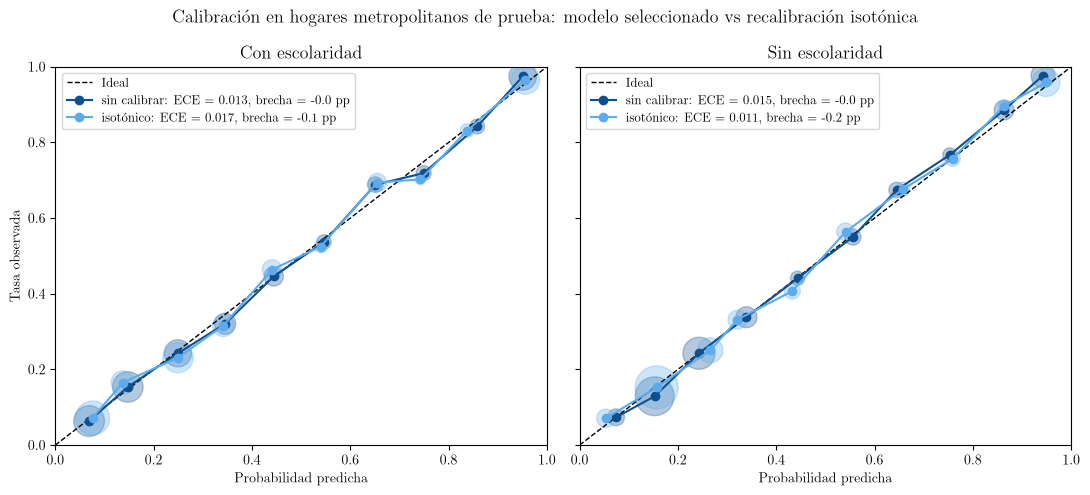

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharey=True)
colors = {"sin calibrar": (0.06, 0.31, 0.55), "isotónico": (0.36, 0.67, 0.93)}
for ax, (title, tables, comparison) in zip(axes, (("Con escolaridad", with_education_comparison_tables, with_education_comparison), ("Sin escolaridad", without_education_comparison_tables, without_education_comparison))):
    ax.plot([0, 1], [0, 1], linestyle="--", color="black", linewidth=1, label="Ideal")
    for label, table in tables.items():
        ax.plot(table["predicted_probability"], table["observed_rate"], marker="o", color=colors[label], label=f"{label}: ECE = {comparison.loc[label, 'ece']:.3f}, brecha = {comparison.loc[label, 'calibration_gap_pp']:+.1f} pp")
        ax.scatter(table["predicted_probability"], table["observed_rate"], s=table["sample_workers"] / 3, color=colors[label], alpha=0.3)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel("Probabilidad predicha")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.legend(fontsize=9)
axes[0].set_ylabel("Tasa observada")
fig.suptitle("Calibración en hogares metropolitanos de prueba: modelo seleccionado vs recalibración isotónica", fontsize=13)
plt.tight_layout()
output_dir = ROOT / "outputs/figures"
output_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(output_dir / "informality_calibration.pdf", bbox_inches="tight")
fig.savefig(output_dir / "informality_calibration.png", dpi=600, bbox_inches="tight")
plt.show()

## Hybrid informality model

The first step in constructing the hybrid informality model is to perform a final refit of the two selected Random Forest specifications using the complete ENOE analytical sample. Since model selection and independent evaluation have already been completed using the training and held-out test subsets, the previously held-out observations can now be reincorporated into the final training data.

For each specification, we create a clean copy of the selected model, preserving its preprocessing pipeline and optimal hyperparameters while discarding the parameters previously learned from the training subset. Each model is then retrained from scratch using all ENOE workers available for the informality modeling stage.

The two final models retain different predictor sets: Model A includes education and will be used for OD workers whose educational information is available, while Model B excludes education and serves as a fallback when this information is unavailable. Sector uncertainty is incorporated later, during prediction, by evaluating informality under each possible economic sector and marginalizing these conditional probabilities using the sector probabilities obtained in the previous notebook.

In [36]:
SHIP_CALIBRATED = False  # which variant is written to outputs/ and the model bundle; both are compared below

final_with_education_model, final_with_education_training = src.refit_informality_model(with_education_best_model, enoe_informality, features=with_education_features, calibrate=False)
final_without_education_model, final_without_education_training = src.refit_informality_model(without_education_best_model, enoe_informality, features=without_education_features, calibrate=False)
final_with_education_calibrated, _ = src.refit_informality_model(with_education_best_model, enoe_informality, features=with_education_features, calibrate=True)
final_without_education_calibrated, _ = src.refit_informality_model(without_education_best_model, enoe_informality, features=without_education_features, calibrate=True)
final_models = {
    "uncalibrated": (final_with_education_model, final_without_education_model),
    "calibrated": (final_with_education_calibrated, final_without_education_calibrated),
}
shipped = "calibrated" if SHIP_CALIBRATED else "uncalibrated"
final_with_education_model, final_without_education_model = final_models[shipped]
print(f"Workers used for final ENOE training: {len(final_with_education_training):,}; shipped variant: {shipped}")

Workers used for final ENOE training: 51,707; shipped variant: uncalibrated


Now we apply the final hybrid informality model to the complete OD worker population. For each worker, we first determine whether educational information is available. If it is, Model A is used; otherwise, Model B is applied.

The selected informality model is then evaluated under each of the four possible economic sectors. For workers with an observed sector, the corresponding sector probability is effectively equal to one, while the remaining sector probabilities are zero. For workers whose sector was previously imputed, the four sector probabilities obtained from the sector-imputation model are retained.

The final probability of informality is therefore obtained by marginalizing over the four possible economic sectors:

$$ P(I_i=1\mid X_i) = \sum_s P(I_i=1\mid X_i,S_i=s)\, P(S_i=s\mid X_i). $$

This allows sector uncertainty from the previous modeling stage to propagate directly into the final informality estimate rather than replacing it with a single hard sector assignment.


In [37]:
od_informality = src.predict_od_informality(final_with_education_model, final_without_education_model, od, with_education_features=with_education_features, without_education_features=without_education_features, training_municipalities=training_municipalities)
od_informality["informal_sampled"] = src.sample_informality(od_informality, random_state=42)  # one Bernoulli draw per worker, unbiased for aggregates
informality_model_usage = src.calculate_informality_model_usage(od_informality)
informality_model_usage.round(4)

support_features = [column for column in with_education_features if column != "sector"]  # sector is marginalized, never scored as no_especificado
unsupported_levels = src.count_levels_without_training_support(src.prepare_informality_features(enoe_informality, support_features), src.prepare_informality_features(od.assign(municipio=od_informality["municipio_scored"]), support_features))
print("OD rows with categorical levels absent from the ENOE training data (scored on their other features):")
display(unsupported_levels)

# OD estimate with the other variant, side by side (overall and within sector, expansion-factor weighted)
alternative = "uncalibrated" if SHIP_CALIBRATED else "calibrated"
od_informality_alternative = src.predict_od_informality(*final_models[alternative], od, with_education_features=with_education_features, without_education_features=without_education_features, training_municipalities=training_municipalities)
def od_summary(frame):
    weights = frame["expansion_factor"]
    summary = {"expected_informality_rate": (weights * frame["prob_informal"]).sum() / weights.sum(), "hard_informality_rate": (weights * frame["informal_predicted"]).sum() / weights.sum()}
    for sector_class in src.SECTOR_CLASSES:
        summary[f"within_{sector_class}"] = (weights * frame[f"prob_informal_sector_{sector_class}"]).sum() / (weights * frame[f"prob_sector_{sector_class}"]).sum()
    return pd.Series(summary)
od_variant_comparison = pd.DataFrame({shipped: od_summary(od_informality), alternative: od_summary(od_informality_alternative)})
od_variant_comparison["difference_pp"] = (od_variant_comparison[alternative] - od_variant_comparison[shipped]) * 100
doubly_imputed = (od_informality["informality_model_used"] == "without_education") & od_informality["sector_fue_imputado"]
print(f"Doubly imputed workers (missing education and imputed sector): {doubly_imputed.sum():,} rows, {od_informality.loc[doubly_imputed, 'expansion_factor'].sum() / od_informality['expansion_factor'].sum():.1%} weighted, mean prob_informal {od_informality.loc[doubly_imputed, 'prob_informal'].mean():.3f} (others {od_informality.loc[~doubly_imputed, 'prob_informal'].mean():.3f})")
print("ENOE benchmark (metro):", round(float(informality_benchmark["weighted_informality_rate"].iloc[0]), 4))
od_variant_comparison.round(4)

OD rows with categorical levels absent from the ENOE training data (scored on their other features):


,feature,rows,levels
0,ocupacion,222,[no_especificado]
1,municipio,750,[no_especificado]
2,estado_civil,143,[no_especificado]
3,parentesco,105,[no_especificado]


Doubly imputed workers (missing education and imputed sector): 4,522 rows, 14.0% weighted, mean prob_informal 0.420 (others 0.369)
ENOE benchmark (metro): 0.3935


,uncalibrated,calibrated,difference_pp
expected_informality_rate,0.3628,0.3622,-0.0667
hard_informality_rate,0.2971,0.3082,1.1104
within_comercio,0.3659,0.3637,-0.2210
within_gobierno_otro_agricultura,0.1706,0.1687,-0.1917
within_manufactura_construccion,0.2579,0.2558,-0.2107
within_servicios_transporte,0.4681,0.4700,0.1911


#### Headline under the sector-imputation sensitivity scenarios

The informality estimate marginalizes over the sector probabilities from the previous stage. Re-running the prediction with the sector probabilities from the two sensitivity scenarios of notebook 04 (shift-weighted refit, delta-adjusted rare class) shows how much the headline depends on the MAR assumption behind the sector imputation. The shipped estimate uses the current imputation.

In [38]:
sensitivity_path = ROOT / "outputs/od_sector_imputed_sensitivity.parquet"
sector_sensitivity_frames = {"current": od}
if sensitivity_path.exists():
    sensitivity_input = pd.read_parquet(sensitivity_path)
    for scenario, frame in sensitivity_input.groupby("scenario"):
        sector_sensitivity_frames[scenario] = frame.drop(columns="scenario").reset_index(drop=True)
headline_sensitivity = pd.DataFrame({
    scenario: od_summary(src.predict_od_informality(final_with_education_model, final_without_education_model, frame, with_education_features=with_education_features, without_education_features=without_education_features, training_municipalities=training_municipalities))
    for scenario, frame in sector_sensitivity_frames.items()
})
for scenario in headline_sensitivity.columns:
    if scenario != "current":
        headline_sensitivity[f"{scenario} − current (pp)"] = (headline_sensitivity[scenario] - headline_sensitivity["current"]) * 100
headline_sensitivity.round(4)

# Workers without a work trip on the survey day have lugar_trabajo = no_especificado and are marginalized over the ENOE
# levels by training share. ENOE suggests most such workers are home-based or mobile (its otro_o_sin_local share, 19%,
# matches the OD's 3% + 12% without a trip), so scoring them as otro_o_sin_local is an upper bound for the headline.
no_trip = src.identify_missing_category(od["lugar_trabajo"])
od_no_trip_upper = src.predict_od_informality(final_with_education_model, final_without_education_model, od, with_education_features=with_education_features, without_education_features=without_education_features, training_municipalities=training_municipalities, level_subsets={"lugar_trabajo": ["otro_o_sin_local"]})
print(f"OD workers without a work trip: {no_trip.sum():,} ({od.loc[no_trip, 'expansion_factor'].sum() / od['expansion_factor'].sum():.1%} weighted); mean P(informal) marginalized {od_informality.loc[no_trip, 'prob_informal'].mean():.3f} vs scored as otro_o_sin_local {od_no_trip_upper.loc[no_trip, 'prob_informal'].mean():.3f}")
print(f"Headline: marginalized {od_summary(od_informality)['expected_informality_rate']:.4f} vs upper bound {od_summary(od_no_trip_upper)['expected_informality_rate']:.4f}")

OD workers without a work trip: 3,290 (13.1% weighted); mean P(informal) marginalized 0.407 vs scored as otro_o_sin_local 0.590
Headline: marginalized 0.3628 vs upper bound 0.4296


In [39]:
from IPython.display import Markdown
u = informality_model_usage.set_index(informality_model_usage.columns[0])
a, b = u.loc["with_education"], u.loc["without_education"]
text = (f"Model A is used for {int(a['sample_workers']):,} workers ({a['sample_share']:.1%} of the sample, {a['weighted_share']:.1%} of the weighted population) and Model B for {int(b['sample_workers']):,} ({b['sample_share']:.1%}; {b['weighted_share']:.1%} weighted) — exactly the workers whose education is missing, so the hybrid dispatch is consistent with the missingness diagnostics.")
display(Markdown(text))

Model A is used for 21,718 workers (80.7% of the sample, 84.2% of the weighted population) and Model B for 5,195 (19.3%; 15.8% weighted) — exactly the workers whose education is missing, so the hybrid dispatch is consistent with the missingness diagnostics.

In [40]:
od_informality_summary = src.calculate_od_informality_summary(od_informality)
od_informality_summary.round(4)

,sample_workers,weighted_population,expected_informal_population,expected_formal_population,expected_informality_rate,hard_informality_rate,hard_sector_expected_rate
0,26913,2272378,824522.1426,1.447856e+06,0.3628,0.2971,0.3724


In [41]:
from IPython.display import Markdown
s = od_informality_summary.iloc[0]
text = (f"The final estimates cover all {int(s['sample_workers']):,} OD workers ({s['weighted_population'] / 1e6:.2f} million after expansion). Summing the individual probabilities gives an expected informal population of {s['expected_informal_population']:,.0f} and a formal population of {s['expected_formal_population'] / 1e6:.2f} million, "
        f"i.e. an expected weighted informality rate of **{s['expected_informality_rate']:.2%}**, the weighted mean of the individual probabilities, which carries the uncertainty of both the informality model and, where applicable, the sector imputation.")
display(Markdown(text))

The final estimates cover all 26,913 OD workers (2.27 million after expansion). Summing the individual probabilities gives an expected informal population of 824,522 and a formal population of 1.45 million, i.e. an expected weighted informality rate of **36.28%**, the weighted mean of the individual probabilities, which carries the uncertainty of both the informality model and, where applicable, the sector imputation.

In [42]:
informality_by_sector = src.calculate_informality_by_sector(od_informality)
informality_by_sector.round(4)

,sector,weighted_population,expected_informal_population,expected_formal_population,expected_informality_rate
0,comercio,699117.6423,255832.5044,443285.1379,0.3659
1,gobierno_otro_agricultura,123957.5695,21148.0031,102809.5665,0.1706
2,manufactura_construccion,622628.8925,160551.3838,462077.5087,0.2579
3,servicios_transporte,826673.8957,386990.2513,439683.6444,0.4681


In [43]:
from IPython.display import Markdown
t = informality_by_sector.set_index("sector"); rate_col = [col for col in t.columns if "rate" in col][0]; r = t[rate_col].sort_values(ascending=False)
text = ("Decomposing the expected informal population by sector (imputed-sector workers contribute fractionally according to their sector probabilities): "
        + ", ".join(f"`{sector}` {value:.1%}" for sector, value in r.items()) + ".")
display(Markdown(text))

Decomposing the expected informal population by sector (imputed-sector workers contribute fractionally according to their sector probabilities): `servicios_transporte` 46.8%, `comercio` 36.6%, `manufactura_construccion` 25.8%, `gobierno_otro_agricultura` 17.1%.

## Comparison of ENOE Results with the Model

In [44]:
import numpy as np
from matplotlib.gridspec import GridSpec

#### Final comparison with ENOE

The discrete OD series shown next to ENOE is **"OD muestreo"**: one Bernoulli draw per worker from `prob_informal` (fixed seed), which is unbiased for every weighted aggregate and is the status the README recommends for downstream use. The 0.5-threshold classification (`informal_predicted`, still in the output file) is not presented as an estimate: it shrinks toward the majority class and, for workers whose sector was marginalized, toward the middle of the scale, so it understates informality by more than 10 percentage points.

ENOE 2023-T1 was collected in January–March 2023 and the OD survey between 23 January and 29 April 2023, so the two sources refer to the same period and no seasonal adjustment is needed.

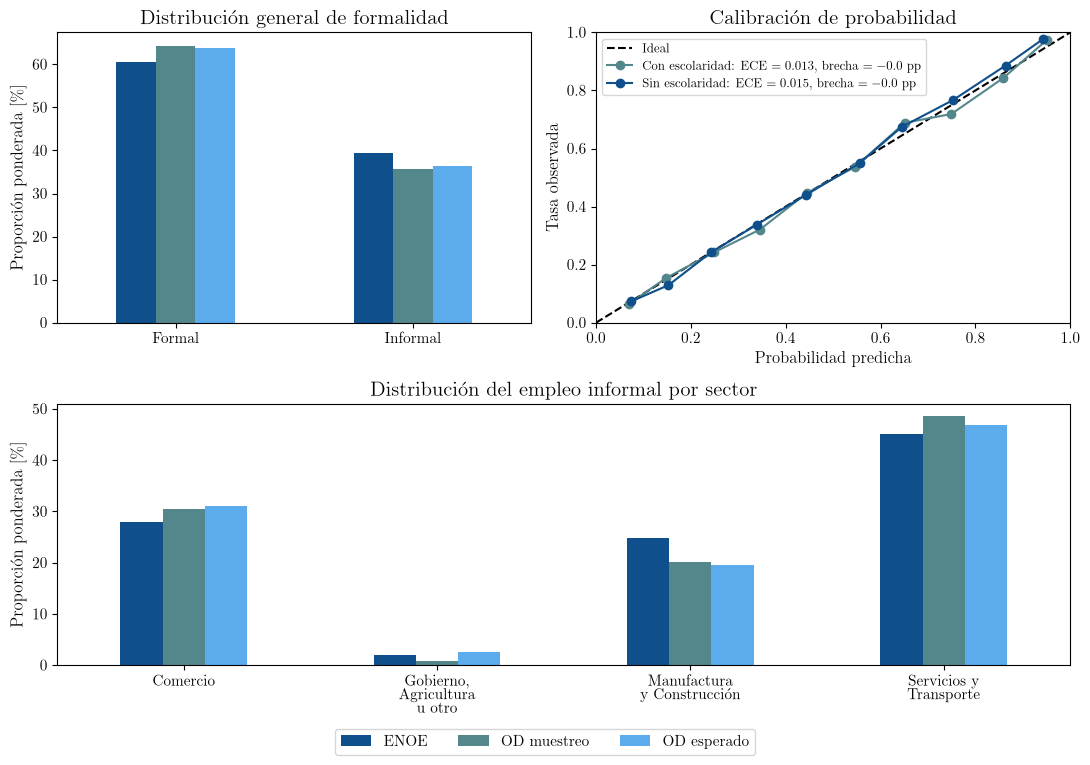

Distribución general formal / informal
           ENOE  OD muestreo  OD esperado
Formal    60.65        64.22        63.72
Informal  39.35        35.78        36.28

Distribución del empleo informal por sector
                                 ENOE  OD muestreo  OD esperado
sector                                                         
Comercio                        28.03        30.43        31.03
Gobierno,\nAgricultura\nu otro   2.00         0.92         2.56
Manufactura\ny Construcción     24.87        20.12        19.47
Servicios y\nTransporte         45.10        48.53        46.94

Tasa de informalidad dentro de cada sector
                                 ENOE  OD muestreo  OD esperado
sector                                                         
Comercio                        47.71        39.63        36.59
Gobierno,\nAgricultura\nu otro  19.24        11.01        17.06
Manufactura\ny Construcción     32.56        25.64        25.79
Servicios y\nTransporte         41.10     

In [45]:
sector_labels = {
    "comercio": "Comercio",
    "gobierno_otro_agricultura": "Gobierno,\nAgricultura\nu otro",
    "manufactura_construccion": "Manufactura\ny Construcción",
    "servicios_transporte": "Servicios y\nTransporte"
}

sector_order = list(sector_labels.keys())

known_color = (0.06, 0.31, 0.55)
assigned_color = (0.33, 0.53, 0.55)
final_color = (0.36, 0.67, 0.93)

# Distribución general formal / informal
enoe_total_population = enoe_benchmark["survey_weight"].sum()
enoe_informal_population = (enoe_benchmark["survey_weight"] * enoe_benchmark["informal"]).sum()
enoe_formal_population = enoe_total_population - enoe_informal_population

od_total_population = od_informality["expansion_factor"].sum()
od_hard_informal_population = od_informality.loc[od_informality["informal_sampled"] == 1, "expansion_factor"].sum()
od_hard_formal_population = od_total_population - od_hard_informal_population
od_expected_informal_population = (od_informality["expansion_factor"] * od_informality["prob_informal"]).sum()
od_expected_formal_population = od_total_population - od_expected_informal_population

overall_formality_distribution = pd.DataFrame({
    "ENOE": [enoe_formal_population / enoe_total_population, enoe_informal_population / enoe_total_population],
    "OD muestreo": [od_hard_formal_population / od_total_population, od_hard_informal_population / od_total_population],
    "OD esperado": [od_expected_formal_population / od_total_population, od_expected_informal_population / od_total_population]
}, index=["Formal", "Informal"]) * 100

# Distribución del empleo informal por sector
od_hard_informal = od_informality[od_informality["informal_sampled"] == 1].copy()
od_hard_by_sector = od_hard_informal.groupby("sector_final")["expansion_factor"].sum().reindex(sector_order, fill_value=0)
od_hard_by_sector = od_hard_by_sector / od_hard_by_sector.sum()

od_expected_by_sector = pd.Series({
    sector: (od_informality["expansion_factor"] * od_informality[f"prob_informal_sector_{sector}"]).sum()
    for sector in sector_order
})
od_expected_by_sector = od_expected_by_sector / od_expected_by_sector.sum()

enoe_informal = enoe_benchmark[enoe_benchmark["informal"] == 1].copy()
enoe_by_sector = enoe_informal.groupby("sector")["survey_weight"].sum().reindex(sector_order, fill_value=0)
enoe_by_sector = enoe_by_sector / enoe_by_sector.sum()

informal_distribution_by_sector = pd.DataFrame({
    "ENOE": enoe_by_sector * 100,
    "OD muestreo": od_hard_by_sector * 100,
    "OD esperado": od_expected_by_sector * 100
})

informal_distribution_by_sector.index = informal_distribution_by_sector.index.map(sector_labels)
informal_distribution_by_sector.index.name = "sector"


# Tasa de informalidad dentro de cada sector
od_hard_sector_population = od_informality.groupby("sector_final")["expansion_factor"].sum().reindex(sector_order, fill_value=0)
od_hard_informal_population_by_sector = od_informality[od_informality["informal_sampled"] == 1].groupby("sector_final")["expansion_factor"].sum().reindex(sector_order, fill_value=0)
od_hard_within_sector = od_hard_informal_population_by_sector / od_hard_sector_population

od_expected_within_sector = pd.Series({
    sector: (
        (od_informality["expansion_factor"] * od_informality[f"prob_informal_sector_{sector}"]).sum()
        /
        (od_informality["expansion_factor"] * od_informality[f"prob_sector_{sector}"]).sum()
    )
    for sector in sector_order
})

enoe_sector_population = enoe_benchmark.groupby("sector")["survey_weight"].sum().reindex(sector_order, fill_value=0)
enoe_informal_population_by_sector = enoe_benchmark[enoe_benchmark["informal"] == 1].groupby("sector")["survey_weight"].sum().reindex(sector_order, fill_value=0)
enoe_within_sector = enoe_informal_population_by_sector / enoe_sector_population

informality_within_sector = pd.DataFrame({
    "ENOE": enoe_within_sector * 100,
    "OD muestreo": od_hard_within_sector * 100,
    "OD esperado": od_expected_within_sector * 100
})

informality_within_sector.index = informality_within_sector.index.map(sector_labels)
informality_within_sector.index.name = "sector"

# Calibración en hogares metropolitanos de prueba (modelo enviado a producción)
calibration_summary = {}
for label, model, features in (("Con escolaridad", with_education_best_model, with_education_features), ("Sin escolaridad", without_education_best_model, without_education_features)):
    metrics_, _, table_ = src.evaluate_informality_model(model, enoe_informality_test, features=features)
    calibration_summary[label] = {"table": table_, "ece": float(metrics_["ece"].iloc[0]), "gap": float(metrics_["calibration_gap_pp"].iloc[0]), "slope": float(metrics_["calibration_slope"].iloc[0])}


# 6) Plots
fig = plt.figure(figsize=(11, 8))
gs = GridSpec(2, 2, figure=fig, height_ratios=[1, 0.9])

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, :])

# Arriba izquierda: Distribución general formal / informal
overall_formality_distribution.plot(kind="bar", ax=ax1, color=[known_color, assigned_color, final_color])

ax1.set_title("Distribución general de formalidad", fontsize=15)
ax1.set_xlabel("")
ax1.set_ylabel(r"Proporción ponderada [\%]", fontsize=12)
ax1.tick_params(axis="x", rotation=0, labelsize=11)
ax1.tick_params(axis="y", labelsize=11)

handles, labels = ax1.get_legend_handles_labels()
ax1.get_legend().remove()

# Arriba derecha: Calibración
ax2.plot([0, 1], [0, 1], linestyle="--", color="black", linewidth=1.5, label="Ideal")

for label, color in (("Con escolaridad", assigned_color), ("Sin escolaridad", known_color)):
    table_ = calibration_summary[label]["table"]
    ax2.plot(table_["predicted_probability"], table_["observed_rate"], marker="o", color=color, label=rf"{label}: ECE $={calibration_summary[label]['ece']:.3f}$, brecha $={calibration_summary[label]['gap']:+.1f}$ pp")

ax2.set_title("Calibración de probabilidad", fontsize=15)
ax2.set_xlabel("Probabilidad predicha", fontsize=12)
ax2.set_ylabel("Tasa observada", fontsize=12)
ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1)
ax2.tick_params(axis="x", labelsize=11)
ax2.tick_params(axis="y", labelsize=11)
ax2.legend(fontsize=9)

# Abajo: distribución del empleo informal por sector
informal_distribution_by_sector.plot(kind="bar", ax=ax3, color=[known_color, assigned_color, final_color])

ax3.set_title("Distribución del empleo informal por sector", fontsize=15)
ax3.set_xlabel("")
ax3.set_ylabel(r"Proporción ponderada [\%]", fontsize=12)
ax3.tick_params(axis="x", rotation=0, labelsize=11)
ax3.tick_params(axis="y", labelsize=11)
ax3.get_legend().remove()

fig.legend(handles, labels, loc="lower center", ncol=3, fontsize=11, bbox_to_anchor=(0.5, 0.04), frameon=True)

output_dir = ROOT / "outputs/figures"
output_dir.mkdir(parents=True, exist_ok=True)

plt.tight_layout(rect=[0, 0.08, 1, 1])

fig.savefig(output_dir / "informality_model_enoe_od_comparison.pdf", bbox_inches="tight")
fig.savefig(output_dir / "informality_model_enoe_od_comparison.png", dpi=600, bbox_inches="tight")

plt.show()

# Tablas resumen
print("Distribución general formal / informal")
print(overall_formality_distribution.round(2))

print("\nDistribución del empleo informal por sector")
print(informal_distribution_by_sector.round(2))

print("\nTasa de informalidad dentro de cada sector")
print(informality_within_sector.round(2))

print("\nCalibración (hogares metropolitanos de prueba)")
for label, values in calibration_summary.items():
    print(f"{label}: ECE = {values['ece']:.4f}, brecha = {values['gap']:+.2f} pp, pendiente = {values['slope']:.3f}")


#### Why is the OD estimate below the ENOE benchmark?

Direct standardization separates the gap between the ENOE metro benchmark and the OD estimate into (i) the model's own bias on ENOE, (ii) the composition effect — the same model applied to ENOE workers reweighted to the OD covariate profile (sex, occupation, age, education, municipality, marital status, household size, sector) — and (iii) a residual attributable to what standardization cannot reproduce: sector imputation, categorical levels without ENOE support and education non-response.

In [46]:
gap_decomposition, gap_reweighting_diagnostics = src.decompose_enoe_od_gap(final_with_education_model, final_without_education_model, enoe_benchmark, od_informality, with_education_features=with_education_features, without_education_features=without_education_features)
print("Reweighting diagnostics (ENOE benchmark rows to the OD profile):"); print(gap_reweighting_diagnostics.round(3).to_string())
gap_decomposition.round(4)

Reweighting diagnostics (ENOE benchmark rows to the OD profile):
rows                       38933.000
effective_sample_size        294.535
top_decile_weight_share        0.353
odds_ratio_median              0.753
odds_ratio_p90                 1.420


,step,rate,interpretation,difference_pp
0,ENOE observed (metro benchmark),0.3935,—,NaN
1,ENOE predicted by the model,0.3946,model bias on ENOE,0.1062
2,"ENOE observed, reweighted to the OD profile",0.3723,composition (observed),-2.1242
3,"ENOE predicted, reweighted to the OD profile",0.3601,composition (predicted),-3.4409
4,OD expected informality,0.3628,"residual: sector imputation, unsupported level...",0.2696


## Export and final validation

In [47]:
od_informality["formalidad_predicha"] = od_informality["informal_predicted"].map({0: "formal", 1: "informal"}).astype("string")

assert len(od_informality) == len(od)
assert od_informality["prob_informal"].notna().all()
assert od_informality["prob_formal"].notna().all()
assert od_informality["informal_predicted"].notna().all()
assert od_informality["prob_informal"].between(0, 1).all()
assert od_informality["prob_formal"].between(0, 1).all()
assert ((od_informality["prob_informal"] + od_informality["prob_formal"] - 1).abs() < 1e-8).all()
assert od_informality["expected_informal_population"].notna().all()
assert od_informality["expected_formal_population"].notna().all()

print("Final informality validation passed.")

Final informality validation passed.


In [48]:
total_population = od_informality["expansion_factor"].sum()
informal_population = od_informality["expected_informal_population"].sum()
formal_population = od_informality["expected_formal_population"].sum()

print(f"Total weighted workers: {total_population:,.0f}")
print(f"Expected informal workers: {informal_population:,.0f}")
print(f"Expected formal workers: {formal_population:,.0f}")
print(f"Population difference: {total_population - informal_population - formal_population:.6f}")

Total weighted workers: 2,272,378
Expected informal workers: 824,522
Expected formal workers: 1,447,856
Population difference: 0.000000


In [49]:
output_directory = ROOT / "outputs"
output_directory.mkdir(exist_ok=True)

output_path = output_directory / "od_informality_imputed.parquet"
od_informality.to_parquet(output_path, index=False)

In [50]:
from joblib import dump

models_directory = ROOT / "outputs/models"
models_directory.mkdir(parents=True, exist_ok=True)

informality_model_bundle = {
    "model_with_education": final_with_education_model,
    "model_without_education": final_without_education_model,
    "features_with_education": with_education_features,
    "features_without_education": without_education_features,
    "sector_classes": src.SECTOR_CLASSES,
    "category_levels": src.build_category_levels(),
    "training_municipalities": sorted(training_municipalities),
    "metadata": {
        "selected": {"with_education": with_education_summary.loc[with_education_summary["selected"], ["model", "best_params", "weighted_log_loss"]].iloc[0].to_dict(), "without_education": without_education_summary.loc[without_education_summary["selected"], ["model", "best_params", "weighted_log_loss"]].iloc[0].to_dict()},
        "test_metrics": {"with_education": with_education_metrics.iloc[0].to_dict(), "without_education": without_education_metrics.iloc[0].to_dict()},
        "enoe_period": src.ENOE_PERIOD, "employment_filter": ENOE_EMPLOYMENT_FILTER if "ENOE_EMPLOYMENT_FILTER" in dir() else "clase2",
        "shipped_variant": shipped, "sklearn_version": __import__("sklearn").__version__, "random_state": 42,
    }
}

model_path = models_directory / "informality_hybrid_model.joblib"
dump(informality_model_bundle, model_path)

print(f"Saved: {model_path}")

Saved: /Users/gperaza/Research/informal-jobs-model/outputs/models/informality_hybrid_model.joblib
